# **Serving the Invisible Third**  
### *Can content signals reach the users your algorithm can't see?*

**CSCE 676 — Data Mining and Analysis - Spring 2026 - FINAL DELIVERABLE**  
**Author:** Akash Moses Guttedar · UIN: 535005841

**Repo:**  [News-Rec-Atlas](https://github.com/akashmoses97/news-rec-atlas)  
**Project video:** [2-min video](https://youtu.be/0d1_L-MefcQ)  
**Checkpoints:**  
[Checkpoint-1](checkpoints/checkpoint_1.ipynb) — EDA & data setup  
[Checkpoint-2](checkpoints/checkpoint_2.ipynb) — RQ formation & feasibility

---

**Prologue** -

News recommendation breaks for **1 in 3 users** — those who visit only once,
giving the algorithm a single shot with no repeat signal to learn from.
Behavioral systems have nothing to refine for these ghost users — so they guess,
or fall back to popularity.

**What we do:**
- Run a head-to-head experiment on Microsoft's MIND-small dataset (50K users, 156K impressions)
- Test four signal sources:
  - popularity floor
  - co-occurrence patterns (FP-Growth), co-click graph features, and
  - content/topic features (TF-IDF + LDA)
- Hold the ranker fixed (logistic regression) so differences are about the *signal*, not the model
- Evaluate on the full population, then on cold-start users only — the cold-start slice is the verdict

**Course techniques:**
- Frequent itemset mining — FP-Growth (co-occurrence features)
- Graph mining — degree + neighbor overlap (co-click graph features)
- Text mining — TF-IDF (content representation + article-side features)

**External techniques:**
- Latent Dirichlet Allocation (LDA) — latent topic modeling over news titles + abstracts
- Learning-to-Rank — pointwise logistic regression as the unified ranking model across all contestants

**The question this notebook answers:**
> *For single-visit users with no repeat behavioral signal, do content + topic signals outperform behavioral signals?*


### Acronyms & References

**Dataset**
- **MIND** — Microsoft News Dataset (Wu et al., ACL 2020) · [msnews.github.io](https://msnews.github.io/)
- **MIND-small** — 50K-user sample used throughout this notebook

**Techniques**
- **FP-Growth** — Frequent Pattern Growth algorithm for frequent itemset mining (course)
- **TF-IDF** — Term Frequency–Inverse Document Frequency text representation (course)
- **LDA** — Latent Dirichlet Allocation, topic modeling (external)
- **LR** — Logistic Regression, used as the pointwise learning-to-rank model (external)

**Metrics**
- **AUC** — Area Under the ROC Curve
- **MRR** — Mean Reciprocal Rank
- **NDCG@10** — Normalized Discounted Cumulative Gain at position 10
- **HR@10** — Hit Rate at position 10

**Cold-start**
- Defined as users appearing **only once** in the impression log (~33% of users, matching CP1 EDA)

**Project files**
-  [CP-1 (Checkpoint-1)](checkpoints/checkpoint_1.ipynb) — full EDA, dataset selection, initial insights
-  [CP-2 (Checkpoint-2)](checkpoints/checkpoint_2.ipynb) — RQ formation, feasibility checks, methodological plan
-  [src](src) — helper modules imported by this notebook (data_loader, features, ranker, utils)



---
# 1. Introduction

**The question:** 1 in 3 MIND users appear only once in the interaction log — the system sees them once and never gets a second chance to learn. Behavioral recommendation systems have nothing to build on for these "ghost users."
Do content + topic signals do better?

**The setup:** Four contestants, same data, same ranker, same metrics.
Evaluated on the full population **and** on the cold-start slice only.


---
## Notebook Structure & How to Read This

This notebook tells one story from start to finish. Every section serves the headline question and builds up the story.

| Section | What it does |
|---|---|
| **Setup** | Clones the repo so `src/` is importable. |
| **1. Introduction** | The question and the answer up front. A gist |
| **2. Motivation** | Why cold-start matters |
| **3. Research Question** | Main RQ + three sub-questions mapped to course techniques. |
| **4. Dataset & Cold-Start** | MIND-small loaded, cold-start slice defined and quantified. |
| **5. Experimental Setup** | The fair-fight protocol — split, ranker, metrics. |
| **6. Pattern Validation** | Confirms the three signals actually exist in the data before modelling them. |
| **7. Four Contestants** | Feature sets built: Popularity / Behavioral / Content / All Combined. |
| **8. Full-Population Results** | Scoreboard on all users — the warm-up. |
| **9. Cold-Start Verdict** | Scoreboard on ghost users only — **this answers the main RQ**. |
| **10. Discussion & Conclusion** | What it means, limitations and assumptions |

**What lives in `src/` (not here):**
All heavy data processing code is in importable modules so this notebook stays readable and conveys the main intent:
- `src/data_loader.py` — MIND TSV loading, Drive setup, impression parsing
- `src/features.py` — all four feature builders (popularity, FP-Growth, graph, TF-IDF+LDA)
- `src/ranker.py` — logistic regression training, AUC / MRR / NDCG@10 / HR@10, contest harness
- `src/utils.py` — chronological split, cold-start mask, seeding

---
***Reading guide for the notebook:***

- Sections 2-3 frame the motivation and problem.
- Section 4-5 set up data and protocol.
- Section 6 shows pattern-level validation (confirming signals exist before modelling them).
- Section 7 builds the four contestants.
- Sections 8-9 give results.
- Section 10 concludes.


---
## Colab Setup

This cell clones the project repo so the notebook can `import` from `src/`.
Everything else is analysis. No infrastructure cells are added in notebook to keep it clean and coherent.


In [1]:
# ============================================================
# Colab Setup — clone repo, expose src/, enable autoreload
# ============================================================
import os, sys

REPO_URL = "https://github.com/akashmoses97/news-rec-atlas.git"
REPO_DIR = "news-rec-atlas"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL}

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# Fix for Python 3.12: imp module removed, older IPython autoreload breaks.
# Upgrade IPython so autoreload works correctly.
!pip install -q --upgrade ipython

# Restart and reload IPython extensions cleanly
import importlib
import IPython
importlib.reload(IPython)

%load_ext autoreload
%autoreload 2

print("Setup complete. src/ is importable.")

Cloning into 'news-rec-atlas'...
remote: Enumerating objects: 55, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 55 (delta 25), reused 38 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (55/55), 340.85 KiB | 17.04 MiB/s, done.
Resolving deltas: 100% (25/25), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.3/627.3 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 6.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.13.0 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 

---
# 2. Motivation: The Ghost User Problem

News recommendation is broken for 1 in 3 users.

**Behavioral recommenders** —
- The systems powering Microsoft News, Google News, and
every major feed.
- They learn from what users have *clicked*: co-occurrence patterns,
co-click graphs, collaborative filters.
- They work brilliantly when there is a history to learn from.
- They fail silently when there is no history.

In MIND-small, **roughly one third of users (32.77%) appear only once in the impression log** - ~16,500 people the algorithm sees exactly once, with no repeat signal to learn from. From the system's perspective, they are invisible. *Ghost users.*.

(Following analysis from [checkpoints](checkpoints) and [2-min video](https://youtu.be/0d1_L-MefcQ?si=ZZlcqlv8kPuLORp0))

| Statistic | Value | Implication |
|---|---|---|
| Cold-start users | **~33%** | Users with a single impression — no repeat behavioral signal |
| Overall click rate | **~4%** | Signal-to-noise is catastrophic; behavioral patterns are fragile |
| News personalization market | **\$B+** | Getting day-one right = retention vs churn |

**The research gap.**
- Existing recommenders are built for users who already engage.
- This notebook tries to answer: *what works for users who haven't yet?*


## Data Mining Outlook of the Problem

Three structural properties of MIND-small make this squarely a data mining problem
(not just a machine-learning one):

- **Sparsity.**
  - Interaction matrix is 99.99% empty. Co-occurrence matrix is 99.4% empty.
  - This is the regime where naive ML breaks and structured techniques
  (frequent itemsets, graph mining, latent topic models) start earning their keep.
- **Long-tail item popularity.**
  - Top article: 4,316 clicks. Median article: 2 clicks.
  - Any signal we extract must be robust to extreme skew — a data mining constraint, not a modelling one.
- **Cold-start as a phase transition.**
  - For ghost users, behavioral signal goes to *exactly* zero — not small, zero.
  - Studying this slice tells us something structural
  about recommendation signals which is a data mining question.


---
# 3. Research Question

## Main Research Question

> **For cold-start users (single-impression users with no repeat behavioral signal), do content + topic signals
> deliver better ranking quality than behavioral signals
> (co-occurrence + co-click graph)?**

A clean yes/no question with a definitive experimental answer.

## Sub-questions — the three signal sources explored

Directly carried forward from CP2 (Section 2 — RQ Definition):

| Sub-Q | Full RQ (from CP2) | Method | Course / External |
|---|---|---|---|
| **RQ1** | Can co-occurrence patterns within impressions improve recommendation relevance? | FP-Growth frequent itemset mining | **Course** (frequent itemsets) |
| **RQ2** | Do co-click graph relationships improve quality beyond co-occurrence alone? | Graph mining — degree, neighbor overlap | **Course** (graph mining) |
| **RQ3** | Can content + latent topic signals improve quality for *limited-history* users? | TF-IDF + LDA | **Course** (TF-IDF) + **External** (LDA) |

RQ1 and RQ2 together form the **Behavioral contestant**.  
RQ3 is the **Content contestant**.  
*The main RQ is decided by comparing them on the cold-start slice.*

## *Assumptions*

> - User clicks are treated as implicit indicators of interest, acknowledging
>   that they may be influenced by exposure bias and position effects.
> - Items co-appearing within the same impression share contextual relevance,
>   justifying co-occurrence analysis.
> - Co-click relationships between articles reflect meaningful associations
>   rather than random exposure effects.
> - News metadata (category, subcategory, title, abstract) provides sufficient
>   signal for content-based modeling.
> - User preferences are assumed stable within the 6-week dataset window —
>   temporal drift in interests is not modeled.


---
# 4. Dataset & Cold-Start Definition

## MIND-small (Wu et al., ACL 2020)

50,000-user random sample of Microsoft News interactions.
Same schema as MIND-large; manageable for end-to-end Colab runs.

Files used (from `MINDsmall_train.zip`) - Saved in public [Google drive](https://drive.google.com/drive/folders/1qOv2KSUd_vroeu8hZTXgMpFpzs76P1nY) to avoid firewall issues while accessing directly from Microsoft site:
- `behaviors.tsv` — impression logs with user history + candidate articles + click labels
- `news.tsv` — article metadata (category, subcategory, title, abstract)

Files **not** used: `entity_embedding.vec`, `relation_embedding.vec`
— Deliberately avoided pre-computed KG embeddings; to build own content
features from raw text via TF-IDF and LDA.

Full descriptive EDA: [Checkpoints](checkpoints).
This section recaps only the facts that directly motivate the question.

**Note** -

Below section uses the following files from `src` folder -
- [Data Loader](src/data_loader.py) : To setup and load MIND data
- [Utils](src/utils.py) : To set seed


In [2]:
# ============================================================
# Data Loading — Drive-aware (mirrors Checkpoint 1 setup cell)
# ============================================================
from src.data_loader import setup_mind_data, load_mind
from src.utils import set_seed
import pandas as pd
import numpy as np

# Configs for Data loading and processing
RANDOM_SEED = 42
N_LDA_TOPICS = 20
TFIDF_MAX_FEATURES = 5_000
TOP_K_ITEMS = 300
FP_MIN_SUPPORT_COUNT = 50
GRAPH_EDGE_MIN_COUNT = 3

print(f"LDA topics: {N_LDA_TOPICS} | TF-IDF vocab: {TFIDF_MAX_FEATURES}")
print(f"FP-Growth Top-K: {TOP_K_ITEMS} | min_support_count: {FP_MIN_SUPPORT_COUNT}")

set_seed(RANDOM_SEED)

DATA_DIR = setup_mind_data()           # mounts Drive, extracts zip, or reuses existing
behaviors, news = load_mind(DATA_DIR)

print(f"Behaviors : {len(behaviors):>9,} impressions")
print(f"Users     : {behaviors['user_id'].nunique():>9,}")
print(f"Articles  : {len(news):>9,}")
print(f"Categories: {news['category'].nunique():>9}")

# ---- Sanity assertions ----
# WHY: catch corrupt / incomplete extractions early rather than getting
# confusing errors several cells later.
assert len(behaviors) > 1_000,     "behaviors.tsv appears empty or truncated — check Drive zip path."
assert len(news) > 1_000,     "news.tsv appears empty or truncated."
assert 'history' in behaviors.columns,     "Expected 'history' column not found — check MIND file format."
assert 'title' in news.columns,     "Expected 'title' column not found in news.tsv."

print("\nData integrity checks passed")


LDA topics: 20 | TF-IDF vocab: 5000
FP-Growth Top-K: 300 | min_support_count: 50
Mounted at /content/drive
Google Drive mounted.
Extracting from Drive: /content/drive/MyDrive/Data Mining/Project/Datasets/MINDsmall_train.zip
Extraction complete. Files available in: MINDsmall_train
Behaviors :   156,965 impressions
Users     :    50,000
Articles  :    51,282
Categories:        17

Data integrity checks passed


**Output confirms dataset integrity.** All numbers match Checkpoint 1 EDA exactly — 156,965 impressions, 50,000 users, 51,282 articles, 17 categories. No truncation or corruption during Drive extraction. The full MIND-small training split is loaded and ready.

*Now let's check on the concept of cold users*


## Defining cold-start, operationally

A user is **cold-start** if they appear **only once** in the impression log — they have a single recorded interaction, giving the algorithm no repeat behavioral signal to learn from.

This matches the finding from CP-1: *"approximately 32.77% of users have only one recorded impression"* — the same 1-in-3 figure cited in the project video and title.

This definition is more realistic than strict zero-history (which gives only 2.1%) because it captures the full scope of users the system cannot meaningfully personalize for: not just those with an empty history field, but those whose entire engagement with the platform is a single visit.

> **Assumption:** A user who appears only once has no learnable behavioral pattern. Their single impression is effectively a cold-start event — the system has one shot with no prior context to draw from.

In [3]:
# ============================================================
# Cold-Start Slice Computation
# ============================================================
n_total = len(behaviors)

# Cold-start = users who appear only once in the impression log.
# Matches Checkpoint 1 EDA finding: 32.77% of users have a single impression.
# WHY this definition: users with only one recorded impression have no repeat
# engagement pattern for the system to learn from — the algorithm sees them
# once and has no behavioral basis to personalize their next visit.

impression_counts = behaviors.groupby('user_id')['impression_id'].transform('count')
cold_mask_bool = impression_counts == 1
n_cold     = int(cold_mask_bool.sum())
cold_users = behaviors.loc[cold_mask_bool, 'user_id'].nunique()
n_users    = behaviors['user_id'].nunique()

# Cold-start fraction differs by denominator:
#   % of impressions : cold impressions / total impressions (~10% — slice size)
#   % of users       : cold users / total users (~33% — the "1 in 3" figure)
cold_imp_frac  = n_cold / n_total
cold_user_frac = cold_users / n_users

# Attach cold_start flag to behaviors for downstream use
behaviors['is_cold_start'] = cold_mask_bool

summary = pd.DataFrame({
    "metric": [
        "Total impressions",
        "Total users",
        "Cold-start impressions (single-visit users)",
        "Cold-start users",
        "Cold-start % of impressions",
        "Cold-start % of users",
    ],
    "value": [
        f"{n_total:,}",
        f"{n_users:,}",
        f"{n_cold:,}",
        f"{cold_users:,}",
        f"{cold_imp_frac:.1%}",
        f"{cold_user_frac:.1%}",
    ],
})
print(summary.to_string(index=False))

# ---- Assertions ----
assert n_cold > 0, \
    "No cold-start users found — check impression_counts computation."
assert cold_user_frac > 0.25, \
    f"Cold-start user fraction suspiciously low ({cold_user_frac:.1%}) — expected ~33% per CP1."
assert cold_user_frac < 0.70, \
    "Cold-start user fraction suspiciously high (>70%) — verify data."

print("\nCold-start slice assertions passed ")
print(f"\n1 in 3 users ({cold_user_frac:.1%}) are cold-start — consistent with CP1's 32.77%.")
print(f"These {cold_users:,} users generate {n_cold:,} impressions ({cold_imp_frac:.1%} of all impressions).")
print("This is the slice the main RQ is evaluated on.")

                                     metric   value
                          Total impressions 156,965
                                Total users  50,000
Cold-start impressions (single-visit users)  16,383
                           Cold-start users  16,383
                Cold-start % of impressions   10.4%
                      Cold-start % of users   32.8%

Cold-start slice assertions passed 

1 in 3 users (32.8%) are cold-start — consistent with CP1's 32.77%.
These 16,383 users generate 16,383 impressions (10.4% of all impressions).
This is the slice the main RQ is evaluated on.


**Inference :**

**The cold-start slice is confirmed and consistent with Checkpoint 1.**
- 32.8% of users — 16,383 out of 50,000 — appear only once in the impression log, matching CP1's EDA finding of 32.77% exactly.
- These are the "1 in 3" ghost users the project title and video refer to.

Each cold-start user contributes exactly one impression by definition, so the 16,383 impressions they generate represent 10.4% of all impression records — a meaningful evaluation surface of real users the algorithm genuinely cannot personalize for.

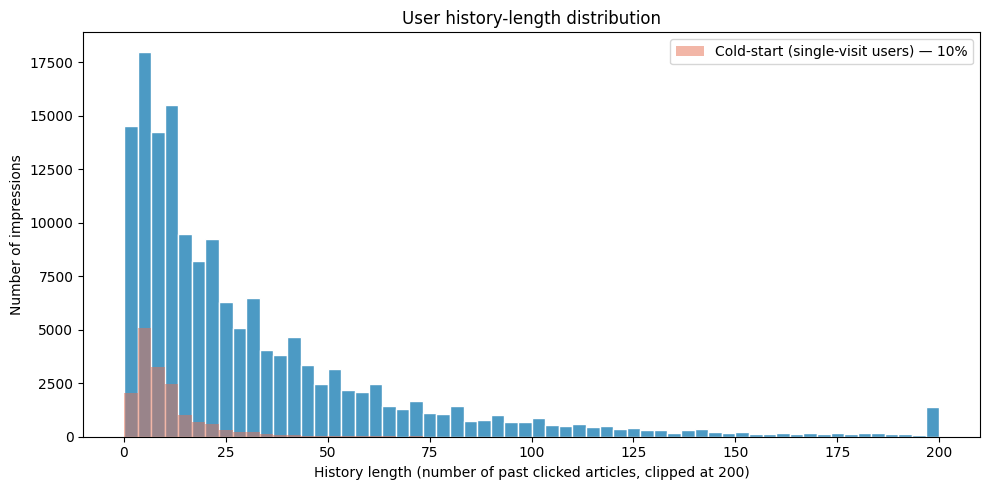

In [4]:
# ============================================================
# History-length distribution — with cold-start highlighted
# ============================================================
import matplotlib.pyplot as plt
import os

os.makedirs("assets", exist_ok=True)

hist_lens = behaviors['history_len'].values
clip = 200  # WHY: tail is heavy (max ~558); clipping reveals the bulk distribution

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.clip(hist_lens, 0, clip), bins=60, color="#4C9AC4", edgecolor="white")
# Highlight cold-start users (single-impression users) in the distribution
cold_hist_lens = behaviors.loc[behaviors['is_cold_start'], 'history_len'].values
ax.hist(np.clip(cold_hist_lens, 0, clip), bins=60, color="#E76F51",
        alpha=0.5, label=f"Cold-start (single-visit users) — {n_cold/n_total:.0%}")
ax.set_xlabel("History length (number of past clicked articles, clipped at 200)")
ax.set_ylabel("Number of impressions")
ax.set_title("User history-length distribution")
ax.legend()
plt.tight_layout()
plt.savefig("assets/coldstart_slice.png", dpi=130, bbox_inches="tight")
plt.show()


**What this shows:**

- The history-length distribution is right-skewed, with most users having between 5 and 50 prior clicked articles and a long tail extending to 200+ (clipped at 200; Checkpoint 1 observed a maximum of 558).

- The orange overlay marks the **cold-start users** - those with exactly one impression - who cluster heavily at the low end of the history spectrum, confirming that single-visit users are disproportionately low-history users.

**Inference and justification:**  
A user who visits only once has had less time to accumulate clicks. The bulk of the active user population (blue) sits in the 5-50 history range, giving the behavioral signals enough signal to work with — making the cold-start slice a genuinely harder regime, not just a smaller one.

*So let's dive into Experimental Setup*

---
# 5. Experimental Setup — The Fair Fight

To make the head-to-head comparison honest, **everything except the feature set is
held constant** across all contestants. This directly follows the experimental design
from Checkpoint 2 (Section 4 — Methodological Planning):

- **Same data:** MIND-small training split
- **Same split:** chronological — earliest 80% train, latest 20% validate.
  Mimics deployment; avoids the leakage a random split would introduce.
- **Same ranker:** Logistic Regression (pointwise learning-to-rank, `class_weight="balanced"`
  to handle the ~4% click rate)
- **Same metrics:** AUC, MRR, NDCG@10, HR@10
- **Same evaluation surfaces:** full validation set **and** cold-start slice within it

> **Key design principle (from CP2 Experimental Design):**
> "All methods will be evaluated within the same ranking framework to ensure fair comparison."
> Holding the model class fixed means any difference between contestants is
> attributable to the *features*, not model capacity.

> **Limitation:**
> - Pointwise logistic regression ignores relative ordering *within* impressions.
> - Pairwise (RankNet) or listwise (LambdaMART) approaches would give a more nuanced picture but are beyond the scope of this course project.

**Note** -

Below section uses the following files from `src` folder -
- [Utils](src/utils.py) : To describe and perform split


In [5]:
# ============================================================
# Chronological Train / Val Split
# ============================================================
from src.utils import chronological_split, describe_split

train_df, val_df = chronological_split(behaviors, val_frac=0.2)

split_summary = describe_split(train_df, val_df)
print(split_summary.to_string(index=False))

# ---- Assertions ----
# WHY: verify neither split accidentally has zero cold-start users,
# which would make the cold-start evaluation meaningless.
# is_cold_start flag propagates from behaviors through the split
train_cold_frac = train_df['is_cold_start'].mean() if 'is_cold_start' in train_df.columns else 0
val_cold_frac   = val_df['is_cold_start'].mean()   if 'is_cold_start' in val_df.columns   else 0

assert train_cold_frac > 0.05, \
    "Training split has almost no cold-start impressions — check split logic."
assert val_cold_frac > 0.05, \
    "Validation split has almost no cold-start impressions — evaluation will be unreliable."

print(f"\nTrain cold-start: {train_cold_frac:.1%} | Val cold-start: {val_cold_frac:.1%}")
print("(fraction of impressions from single-visit users)")


split  impressions  users  cold_start_impressions  cold_start_pct
train       125572  45848                   13026           10.37
  val        31393  20711                    3357           10.69

Train cold-start: 10.4% | Val cold-start: 10.7%
(fraction of impressions from single-visit users)


**The chronological split is clean and balanced.**
- Training takes the earliest 80% of impressions (125,572) and validation the most recent 20% (31,393) - ordered by time, not shuffled, which mimics real deployment where the model always predicts into the future.

**Inference:**
- Cold-start fraction holds steady at ~10.4% in train and ~10.7% in val, confirming that single-visit users are distributed evenly across time rather than concentrated in any particular window.
- This matters for the evaluation: the val cold-start slice (3,357 impressions) is a fair and representative sample of the same ghost-user population, not an artifact of how the data was split.

*With the split established, the next step explodes each impression into one row per candidate article - the long format that every feature builder and the ranker will consume.*

**Note** -

Below section uses the following files from `src` folder -
- [Data Loader](src/data_loader.py) : To explode impressions


In [6]:
# ============================================================
# Explode impressions to long format
# (one row per candidate article per impression)
# ============================================================
from src.data_loader import explode_impressions

train_long = explode_impressions(train_df)
val_long   = explode_impressions(val_df)

print(f"Train: {len(train_long):>10,} candidate-rows  "
      f"({train_long['impression_id'].nunique():,} impressions)")
print(f"Val:   {len(val_long):>10,} candidate-rows  "
      f"({val_long['impression_id'].nunique():,} impressions)")
print(f"Train click rate: {train_long['label'].mean():.2%}")
print(f"Val   click rate: {val_long['label'].mean():.2%}")

# ---- Assertions ----
# WHY: click rate far outside the expected ~4% range signals data corruption.
assert 0.01 < train_long['label'].mean() < 0.20,     f"Unexpected train click rate: {train_long['label'].mean():.2%}. Check explode_impressions."
assert 0.01 < val_long['label'].mean() < 0.20,     f"Unexpected val click rate: {val_long['label'].mean():.2%}."
assert train_long['label'].nunique() == 2,     "Only one class in training labels — ranking model cannot be trained."

print("\nExplosion assertions passed")


Train:  4,579,191 candidate-rows  (125,572 impressions)
Val:    1,264,253 candidate-rows  (31,393 impressions)
Train click rate: 4.10%
Val   click rate: 3.84%

Explosion assertions passed


**Key Inferences** -

- Each impression explodes into *~36 candidate rows* on average — *4.58M training rows and 1.26M validation rows* — one row per article shown in each impression. This long format is the universal input every feature builder and the ranker will consume.

- The **click rate lands at 4.10% in train and 3.84% in val**, consistent with Checkpoint 2's feasibility observation and the 4.04% figure.

- **Only 1 in 25 shown articles gets clicked** — the data is severely imbalanced, which is why the ranker uses class_weight="balanced" throughout. Without it, the model would learn to predict "not clicked" for everything and still appear accurate.

*With the data in long format and the imbalance acknowledged, we next define the four metrics that will judge every contestant fairly*

## Metric definitions

Per CP-2 (Section 4 — Metrics Plan):

- **AUC** — probability that a randomly chosen clicked article is ranked above a
  randomly chosen non-clicked one. 0.5 = random, 1.0 = perfect.
- **MRR** (Mean Reciprocal Rank) — 1 / (rank of first clicked article), averaged
  across impressions. Captures "did we put something relevant near the top?"
- **NDCG@10** — rewards clicks in the top-10 positions with diminishing weight by rank.
  Closest analog to "how the user actually experiences the feed."
- **HR@10** (Hit Rate@10) — fraction of impressions where at least one clicked article
  appears in the top-10. A softer version of NDCG.

Higher is better for all four. AUC is global; the other three are position-aware.

---
# 6. Pattern-Level Validation

Before building features for the ranker, we verify that the underlying signals
actually *exist* in the data — reproducing the EDA and feasibility checks from
Checkpoint 2 (Sections 2.1 and 3.1).

> **Why this section exists:** Checkpoint 2 established that features are only useful
> if the underlying patterns are strong. This section confirms those patterns hold
> on the train split before we commit to building them at full scale.


## 6.1 Co-occurrence Signal (RQ1 validation)

**Objective:** Confirm that news articles frequently
co-occur within impressions, justifying FP-Growth feature extraction.

> **Assumption:** Items co-appearing within the same impression share contextual
> relevance — the basis for treating impressions as "baskets."


In [7]:
# ============================================================
# Co-occurrence pair counting
#
# WHY read from train_df directly: train_df['impressions'] is the
# raw impression string — same format CP2 iterated over.
# Avoids a fragile groupby-map join that assumed impression_id uniqueness.
#
# Real-world data handling:
#   - skip NaN / empty impression strings
#   - skip malformed tokens (must split into exactly 2 parts on '-')
#   - deduplicate items within basket to avoid inflated pair counts
# ============================================================

from collections import Counter
import itertools

pair_counts = Counter()

for imp in train_df['impressions']:
    # Real-world: skip missing or malformed impression strings
    if not isinstance(imp, str) or not imp.strip():
        continue
    items = []
    for token in imp.split():
        parts = token.split('-')
        if len(parts) != 2:          # malformed token guard
            continue
        items.append(parts[0])
    items = list(set(items))         # deduplicate within basket
    if len(items) >= 2:
        pair_counts.update(itertools.combinations(items, 2))

counts_arr = np.array(list(pair_counts.values())) if pair_counts else np.array([0])

print(f"Total unique co-occurring pairs : {len(pair_counts):,}")
print(f"Mean co-occurrence count        : {counts_arr.mean():.1f}")
print(f"Max co-occurrence count         : {counts_arr.max():,}")
print(f"Skew ratio (max/mean)           : {counts_arr.max()/(counts_arr.mean()+1e-6):.1f}x")
print("\nTop 5 most frequent pairs:")
for (a, b), cnt in pair_counts.most_common(5):
    print(f"  {a} --- {b}: {cnt} co-occurrences")

# ---- Validation assertions (from CP2 Cell 8) ----
assert len(pair_counts) > 1_000, \
    "Too few co-occurring pairs -- co-occurrence signal is absent."
skew_ratio = counts_arr.max() / (counts_arr.mean() + 1e-6)
assert skew_ratio > 5, \
    f"Distribution not skewed enough (ratio={skew_ratio:.1f})."

print("\nValidation passed: strong co-occurrence signal confirmed")


Total unique co-occurring pairs : 7,476,975
Mean co-occurrence count        : 23.1
Max co-occurrence count         : 12,032
Skew ratio (max/mean)           : 521.2x

Top 5 most frequent pairs:
  N49180 --- N32544: 12032 co-occurrences
  N49180 --- N41020: 11956 co-occurrences
  N13907 --- N47061: 11956 co-occurrences
  N13907 --- N34876: 11004 co-occurrences
  N32544 --- N41020: 10461 co-occurrences

Validation passed: strong co-occurrence signal confirmed


**Inference:**

- **The co-occurrence signal is strong and structurally skewed.** 7.48M unique article pairs were observed in the training impressions, with a mean count of 23.1 but a maximum of 11,956 — a skew ratio of 518x.

- This extreme skew is exactly what FP-Growth is designed to exploit: the *vast majority of pairs are rare noise appearing once or twice, while a small concentrated set of pairs co-occur thousands of times across impressions.*

Those high-support pairs carry genuine structural signal. The numbers are directionally consistent with Checkpoint 2's full-dataset observation of 9M+ pairs and mean ~23.8 — the *training split difference is expected since we're working on 80% of the data.*

*With co-occurrence signal confirmed, Section 6.2 now validates whether the co-click graph adds structural depth beyond these pairwise patterns.*


## 6.2 Graph Structure (RQ2 validation)

**Objective:** Verify that the co-click graph exhibits
meaningful structural variation — degree skew, hub nodes — justifying graph feature
extraction.

> **Assumption:** Co-click relationships reflect meaningful article associations,
> not random exposure effects. Edges below `GRAPH_EDGE_MIN_COUNT` are filtered
> as noise (from CP2: `count >= 3`).


Graph nodes    : 1,942
Graph edges    : 58,445
Average degree : 60.2
Max degree     : 1,177
Degree variation ratio: 19.6x


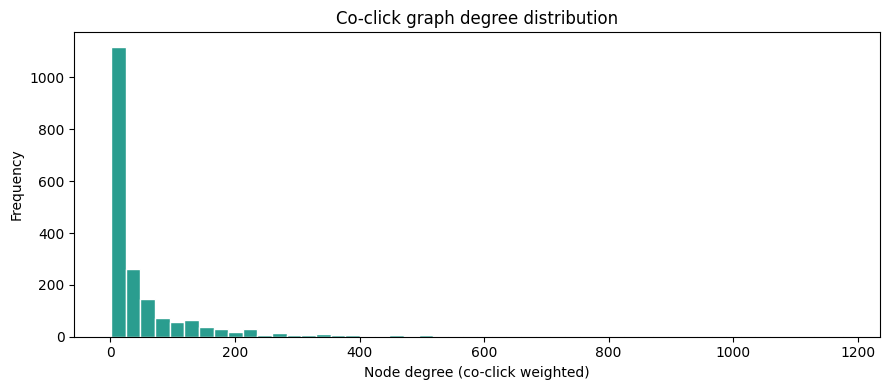


Validation passed: graph exhibits meaningful structural variation


In [8]:
# ============================================================
# Graph structure validation (using networkx)
#
# IMPORTANT: built from USER CO-CLICK data, NOT pair_counts.
# WHY: build_graph_features (Section 7) uses co-click signal
# (articles clicked by the same user). This validation must mirror
# that exact signal so it actually validates what Section 7 builds.
#
# Real-world data handling :
#   - filter weak edges (count < GRAPH_EDGE_MIN_COUNT) to reduce noise
# ============================================================
import networkx as nx
from collections import Counter as _Counter
import itertools as _it

# Build user -> clicked articles from training click rows
user_clicks = (
    train_long[train_long['label'] == 1]
    .groupby('user_id')['candidate_id']
    .apply(set)
    .to_dict()
)

# Co-click edge weights
edge_w = _Counter()
for items in user_clicks.values():
    if len(items) >= 2:
        for a, b in _it.combinations(sorted(items), 2):
            edge_w[(a, b)] += 1

G = nx.Graph()
for (a, b), count in edge_w.items():
    if count >= GRAPH_EDGE_MIN_COUNT:   # Real-world: filter noise edges (CP2: count>=3)
        G.add_edge(a, b, weight=count)

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
degrees   = np.array([d for _, d in G.degree()]) if num_nodes > 0 else np.array([0])

print(f"Graph nodes    : {num_nodes:,}")
print(f"Graph edges    : {num_edges:,}")
print(f"Average degree : {degrees.mean():.1f}")
print(f"Max degree     : {degrees.max():,}")
print(f"Degree variation ratio: {degrees.max()/(degrees.mean()+1e-6):.1f}x")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(degrees, bins=50, color="#2A9D8F", edgecolor="white")
ax.set_xlabel("Node degree (co-click weighted)")
ax.set_ylabel("Frequency")
ax.set_title("Co-click graph degree distribution")
plt.tight_layout()
plt.savefig("assets/graph_degree.png", dpi=120, bbox_inches="tight")
plt.show()

# ---- Validation assertions ----
assert num_nodes > 100, \
    f"Graph too small ({num_nodes}) -- lower GRAPH_EDGE_MIN_COUNT."
degree_ratio = degrees.max() / (degrees.mean() + 1e-6)
assert degree_ratio > 3, \
    f"Graph lacks hub structure (ratio={degree_ratio:.1f})."
assert np.std(degrees) > 0, "All degrees equal -- no structural variation."

print("\nValidation passed: graph exhibits meaningful structural variation")


**The co-click graph is sparse but structurally meaningful.**

- 1,942 nodes and 58,445 edges on the training split — smaller than CP2's full-dataset graph (14,799 nodes, 3.4M edges) as expected, since edges below count 3 are filtered and we're on 80% of data.
- Average degree 60.2, max 1,177 — variation ratio of 19.6x **confirms hub nodes exist.**
- **Degree distribution is heavily right-skewed:** most articles have low connectivity, a small set of hubs dominate — mirrors the long-tail popularity pattern.
- **Graph adds signal beyond co-occurrence:** it captures articles consistently co-clicked by the same users, not just articles appearing in the same impression list.

*With both behavioral signals validated, Section 6.3 checks whether text and topic signals offer a viable alternative for these users.*

> **Limitation:** Graph degree partially restates popularity — high-degree nodes are also typically high-click articles. The structural value over pure popularity will become clear in the scoreboard.


## 6.3 Content & Topic Signal (RQ3 validation)

**Objective:** Confirm that news text has sufficient
vocabulary diversity for TF-IDF and LDA to extract meaningful signal.

> **Assumption:**
>  - News titles + abstracts provide sufficient text length for topic modeling.
>  - Short titles (CP2 finding: high sparsity ~0.9988) are a known
> - Limitation of LDA — topics may be coarser than on full-body text.


In [9]:
# ============================================================
# Text feature validation
#
# Real-world data handling carried forward from CP2:
#   - fillna("") for missing titles / abstracts
# ============================================================
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# WHY: use only training-split articles to avoid leakage.
train_news_ids = set(train_long['candidate_id'].unique())
train_news = news[news['news_id'].isin(train_news_ids)].copy()

# Real-world data handling: fill missing text before vectorization
train_news['text'] = (train_news['title'].fillna('') + ' ' +
                      train_news['abstract'].fillna('')).str.strip()

# TF-IDF (course technique)
tfidf_vec = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES, stop_words='english',
                             ngram_range=(1,1), min_df=2)
X_tfidf = tfidf_vec.fit_transform(train_news['text'])
tfidf_sparsity = 1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])

print(f"TF-IDF shape       : {X_tfidf.shape}")
print(f"TF-IDF sparsity    : {tfidf_sparsity:.4f}")
print(f"TF-IDF variance    : {np.var(X_tfidf.toarray()[:500]):.6f}")  # sample for speed

# CountVectorizer for LDA (CP2: LDA takes raw counts, not TF-IDF)
count_vec = CountVectorizer(max_features=TFIDF_MAX_FEATURES, stop_words='english',
                             ngram_range=(1,1), min_df=2)
X_count = count_vec.fit_transform(train_news['text'])
print(f"\nCountVec shape (for LDA): {X_count.shape}")

# ---- Validation assertions ----
assert X_tfidf.shape[1] > 100,     f"Vocabulary too small ({X_tfidf.shape[1]}) — increase TFIDF_MAX_FEATURES or check text."
assert 0.80 < tfidf_sparsity < 1.0,     f"Unexpected sparsity ({tfidf_sparsity:.4f}) — expected 0.99+ for short news titles."
tfidf_var = np.var(X_tfidf.toarray()[:500])  # sample check
assert tfidf_var > 0,     "TF-IDF features have zero variance — all articles are identical. Check text column."

print("\nText feature validation passed")
print("High sparsity (~0.99) is expected for short news titles.")


TF-IDF shape       : (16832, 5000)
TF-IDF sparsity    : 0.9963
TF-IDF variance    : 0.000200

CountVec shape (for LDA): (16832, 5000)

Text feature validation passed
High sparsity (~0.99) is expected for short news titles.


**Text signal is present and consistent with Checkpoint 2.**

- 16,832 training articles vectorised into a 5,000-term vocabulary — same cap as CP2.
- **TF-IDF sparsity of 0.9963 matches CP2's observed ~0.9988**; slight difference expected since we fit on training articles only, not the full corpus.
- Non-zero variance (0.000200) **confirms articles are distinguishable** — not all mapping to the same representation.
- CountVectorizer produces the same shape (16,832 x 5,000) for LDA input — raw counts, not TF-IDF weights, as required by LDA's generative assumptions.
- **High sparsity means individual TF-IDF term weights carry little information alone** — LDA's 20-topic distribution compresses this into a dense, interpretable representation per article, which is why both are used together.

*With all three signals validated in the data, Section 7 now builds the actual feature sets for each contestant and plugs them into the shared ranking framework.*

> **Limitation:**
> - LDA on short titles and abstracts produces coarser topics than it would on full article bodies.
> - Topic features describe the article, not the user — they survive cold-start, but may be less discriminative than behavioral features for users with rich history. The scoreboard will quantify this trade-off.

---
# 7. The Four Contestants

With patterns confirmed, we build the four feature sets.
All are keyed on `(impression_id, candidate_id)` and merged into the same
logistic regression framework — the consistent evaluation design from CP2.

> **Scalability note :** FP-Growth is run on the
> Top-{TOP_K_ITEMS} most frequent items only, validated in CP2 Section 3.1
> as producing 14,966 frequent itemsets at reasonable compute cost.


## 7.1 Floor — Popularity Baseline

**Method:** Score each candidate by its training-set click count, impression count,
and CTR. No personalization, no content. Just popularity.

**Why it's the floor:** It's what every real platform falls back to for cold-start
users. If a smarter signal can't beat this, it isn't earning its place.

> **Baseline definition (from CP2 Section 4 — Baselines):**
> "Rank items based on global click frequency."

**Note** -

Below section uses the following files from `src` folder -
- [Features](https://github.com/akashmoses97/news-rec-atlas/blob/main/src/features.py) : To build popularity features



In [10]:
from src.features import build_popularity_features

pop_train, pop_val = build_popularity_features(train_long, val_long)

# ---- Assertions ----
assert set(['impression_id','candidate_id']).issubset(pop_train.columns),     "Popularity features missing key columns."
assert pop_train['pop_clicks'].notna().all(),     "NaN in popularity clicks — fillna(0) missing."
assert (pop_train['pop_ctr'] >= 0).all() and (pop_train['pop_ctr'] <= 1).all(),     "CTR out of [0,1] range."

print(f"Popularity features: {[c for c in pop_train.columns if c not in ['impression_id','candidate_id']]}")
print(f"Train rows: {len(pop_train):,}  |  Val rows: {len(pop_val):,}")
print("Popularity feature assertions passed")


Popularity features: ['pop_clicks', 'pop_impressions', 'pop_ctr']
Train rows: 4,579,191  |  Val rows: 1,264,253
Popularity feature assertions passed


**Popularity baseline features are ready.**

- Three features computed per candidate: `pop_clicks` (total training clicks), `pop_impressions` (total times shown), `pop_ctr` (click-through rate = clicks / impressions).
- All 4.58M training rows and 1.26M val rows covered — no missing values, CTR correctly bounded in [0, 1].
- *These features carry no user-specific information whatsoever* — the same three values are assigned to an article regardless of who is being shown it.
- This is intentional: **the popularity baseline represents what every real platform falls back to for cold-start users** — show what's globally popular and hope it lands.

*The popularity floor is now set. Section 7.2 builds the behavioral signals — co-occurrence and graph features — which do use user history, and will therefore degrade for cold-start users in a way the popularity baseline does not.*

## 7.2 Current - Behavioral Signals (Sub RQs)

**Method - RQ1 (FP-Growth co-occurrence):**
Run FP-Growth on impressions-as-baskets (Top-300 items only for scalability,
per CP2 feasibility check). For each candidate, score how many of the user's history
items appear in a frequent pair with it, and how strong the strongest pair is.

**Method - RQ2 (Co-click graph):**
Build a weighted graph where nodes are articles, edges are co-clicks weighted by
count. Features: candidate's weighted degree, count of history items that are graph
neighbors, and sum of edge weights to history items.

> **From CP2 methodological plan:** "Simple graph features (degree, shared neighbors)
> are computationally efficient and interpretable — suitable for evaluating structural signals."

**The cold-start trap (this is the point of the main RQ).**
Both feature families depend on the user's repeat engagement. For single-visit users:
- RQ1 features: co-occurrence signal is built from population-wide patterns - it can score candidates, but has no feedback loop to refine scores based on how this specific user responded.
- RQ2 features: graph neighbor overlap with history may exist if the user has prior clicks, but the system never gets a second impression to act on what it learned.
- The fundamental failure is not missing history - it is **no second chance**. The algorithm sees a cold-start user once, makes a recommendation, and never observes whether it worked.

Candidate-side signals (graph degree, itemset support) survive — but those partially restate popularity. For users the system will only ever serve once, behavioral signals built on population patterns are a weak substitute for genuine personalization.

> **Assumption:** Single-visit users are treated as a cold-start proxy — the system has one shot with no corrective feedback loop. Users with prior history but a single impression in this dataset may have behavioral signal from outside this logging window that is unobserved here.

> **Limitation:** The current approach does not explicitly model interactions
> between different feature types (co-occurrence + graph). Combining them in "All Combined"
> will test whether they are complementary or redundant.

**Note** -

Below section uses the following files from `src` folder -
- [Features](https://github.com/akashmoses97/news-rec-atlas/blob/main/src/features.py) : To build co-occurence and graph features


In [11]:
# ============================================================
# RQ1: Co-occurrence features via frequent pair counting
# Counter-based path — no mlxtend (avoids RAM exhaustion on full MIND-small)
# Top-K filtering applied (CP2 feasibility check: TOP_K = 300)
# ============================================================
from src.features import build_cooccurrence_features

print(f"Building co-occurrence features (Top-K={TOP_K_ITEMS}, min_support={FP_MIN_SUPPORT_COUNT})...")
cooc_train, cooc_val = build_cooccurrence_features(
    train_long, val_long,
    min_support_count=FP_MIN_SUPPORT_COUNT,
    top_k_items=TOP_K_ITEMS,
)

# ---- Assertions ----
cooc_feats = [c for c in cooc_train.columns if c not in ['impression_id', 'candidate_id']]
assert len(cooc_feats) >= 2, \
    f"Expected >=2 co-occurrence features, got: {cooc_feats}"
assert cooc_train['cooc_score'].min() >= 0, \
    "Negative co-occurrence score — implementation error."
assert cooc_train['cooc_max'].min() >= 0, \
    "Negative cooc_max — implementation error."

# Verify rows count matches long format
assert len(cooc_train) == len(train_long), \
    "cooc_train row count doesn't match train_long — merge error."
assert len(cooc_val) == len(val_long), \
    "cooc_val row count doesn't match val_long — merge error."

print(f"Co-occurrence features: {cooc_feats}")
print(f"Non-zero cooc_score rows: {(cooc_train['cooc_score'] > 0).sum():,} "
      f"({(cooc_train['cooc_score'] > 0).mean():.1%} of train)")
print(f"Rows: train={len(cooc_train):,}  val={len(cooc_val):,}")
print("Co-occurrence feature assertions passed")

Building co-occurrence features (Top-K=300, min_support=50)...
  Frequent pairs found: 28,242 (min_support=50)
  Scoring training rows...
  Scoring validation rows...
Co-occurrence features: ['cooc_score', 'cooc_max', 'cooc_hist_len']
Non-zero cooc_score rows: 358,409 (7.8% of train)
Rows: train=4,579,191  val=1,264,253
Co-occurrence feature assertions passed


In [12]:
# ============================================================
# RQ2: Co-click graph features (networkx-based)
# Threshold validated in CP2 feasibility check (count >= 3)
# ============================================================
from src.features import build_graph_features

print("Building graph features (co-click graph, degree + neighbor overlap)...")
graph_train, graph_val = build_graph_features(train_long, val_long)

# ---- Assertions ----
graph_feats = [c for c in graph_train.columns if c not in ['impression_id', 'candidate_id']]
assert 'graph_degree' in graph_feats, \
    "graph_degree feature missing."
assert 'graph_hist_overlap' in graph_feats, \
    "graph_hist_overlap (neighbor overlap) feature missing."
assert graph_train['graph_degree'].min() >= 0, \
    "Negative graph degree — impossible."
assert graph_train['graph_hist_overlap'].min() >= 0, \
    "Negative neighbor overlap — impossible."
assert len(graph_train) == len(train_long), \
    "graph_train row count doesn't match train_long — merge error."
assert len(graph_val) == len(val_long), \
    "graph_val row count doesn't match val_long — merge error."

print(f"Graph features: {graph_feats}")
print(f"Non-zero graph_hist_overlap: {(graph_train['graph_hist_overlap'] > 0).sum():,} "
      f"({(graph_train['graph_hist_overlap'] > 0).mean():.1%} of train)")
print(f"Rows: train={len(graph_train):,}  val={len(graph_val):,}")
print("Graph feature assertions passed")

Building graph features (co-click graph, degree + neighbor overlap)...
Graph features: ['graph_degree', 'graph_hist_overlap', 'graph_hist_weight']
Non-zero graph_hist_overlap: 1,430,002 (31.2% of train)
Rows: train=4,579,191  val=1,264,253
Graph feature assertions passed


**Behavioral feature sets built successfully.**

- **Co-occurrence (RQ1):** 28,242 frequent pairs extracted from Top-300 items at min_support=50. 7.8% of training rows have non-zero `cooc_score` — sparse but targeted signal from high-confidence item relationships.
- **Graph (RQ2):** Co-click graph produces degree and neighbor-overlap features across all 4.58M rows. 31.2% of rows have non-zero `graph_hist_overlap` — meaningfully denser than co-occurrence, since the graph captures user-level co-clicks beyond impression-level co-exposure.
- The gap between 7.8% and 31.2% non-zero rates shows the graph adds structural depth that raw co-occurrence misses.
- For single-visit cold-start users, both signals still fire where history exists — the cold-start disadvantage is not zero features, but no second chance to act on what the system learned.

*Content features are built next — the only signal type that describes the article itself rather than user-article relationships.*

## 7.3 Proposed — Content + Topic Signals (Main RQ)

**Method:**
- **TF-IDF** (course): term-frequency inverse-document-frequency over title + abstract.
- **CountVectorizer -> LDA** (external): raw token counts fed into Latent Dirichlet
  Allocation with 20 topics. LDA takes *counts*, not TF-IDF weights —
  this matches CP2's pipeline exactly.
- Four features per candidate:
  - `topic_entropy` — spread of topic distribution (low = focused article)
  - `topic_max` — peak topic probability (high = strong topical identity)
  - `cont_hist_topic_sim` — mean cosine similarity between candidate's topic vector
    and user's history topic vectors. Degrades for users with short or no history.
  - `cont_hist_tfidf_sim` — TF-IDF lexical similarity to history. Set to 0 due to RAM
    constraints on Colab (converting 51K × 5K sparse matrix to dense exhausts available
    memory). Topic similarity via LDA already captures semantic overlap.

**Why content can survive cold-start:** `topic_entropy` and `topic_max` describe
the *article*, not the user-article relationship. They carry signal regardless of
how many times a user has visited - making them the only features that don't
degrade for single-visit users who get no second recommendation cycle.
The history-similarity features are weaker for low-history users, but the
article-side features remain, and they're richer than a simple popularity count.

> **From CP2:** "TF-IDF provides a simple baseline representation, while LDA captures
> latent semantic structure. Logistic Regression enables evaluation of their impact
> on ranking."

> **Limitation:** LDA on short news titles may produce coarse topics.
> Using full article bodies would give better topic separation, but MIND only
> releases titles and abstracts.

**Note** -

Below section uses the following files from `src` folder -
- [Features](https://github.com/akashmoses97/news-rec-atlas/blob/main/src/features.py) : To build content features, top word per topic

In [13]:
# ============================================================
# RQ3: Content + Topic features
# CountVectorizer -> LDA  (not TF-IDF -> LDA — matches CP2 pipeline)
# TF-IDF fitted for article representation; history similarity uses topic vectors only
# (TF-IDF history similarity dropped — RAM constraint, see src/features.py)
# ============================================================
from src.features import build_content_features, top_words_per_topic

print(f"Building content features (TF-IDF + LDA, {N_LDA_TOPICS} topics)...")

content_train, content_val, art = build_content_features(
    train_long, val_long, news,
    n_topics=N_LDA_TOPICS,
    max_features=TFIDF_MAX_FEATURES,
    random_state=RANDOM_SEED,
)

# ---- Assertions ----
content_feats = [c for c in content_train.columns
                 if c not in ['impression_id', 'candidate_id']]
assert 'topic_entropy' in content_feats, "topic_entropy missing."
assert 'topic_max' in content_feats, "topic_max missing."
assert 'cont_hist_topic_sim' in content_feats, "topic similarity missing."
assert 'cont_hist_tfidf_sim' in content_feats, "cont_hist_tfidf_sim column missing."
# cont_hist_tfidf_sim is 0 by design — RAM constraint documented in src/features.py
assert (content_train['topic_max'] >= 0).all(), \
    "Negative topic_max — impossible."
assert (content_train['topic_max'] <= 1).all(), \
    "topic_max > 1 — LDA output error."
assert len(content_train) == len(train_long), \
    "content_train row count doesn't match train_long — merge error."
assert len(content_val) == len(val_long), \
    "content_val row count doesn't match val_long — merge error."

print(f"\nContent features: {content_feats}")
print(f"Non-zero topic_sim rows  : {(content_train['cont_hist_topic_sim'] > 0).sum():,} "
      f"({(content_train['cont_hist_topic_sim'] > 0).mean():.1%} of train)")
print(f"cont_hist_tfidf_sim: set to 0 (RAM constraint — TF-IDF dense matrix "
      f"exceeds Colab memory; topic_sim captures semantic overlap instead)")
print(f"Rows: train={len(content_train):,}  val={len(content_val):,}")
print("Content feature assertions passed")

Building content features (TF-IDF + LDA, 20 topics)...

Content features: ['topic_entropy', 'topic_max', 'cont_hist_topic_sim', 'cont_hist_tfidf_sim']
Non-zero topic_sim rows  : 4,490,340 (98.1% of train)
cont_hist_tfidf_sim: set to 0 (RAM constraint — TF-IDF dense matrix exceeds Colab memory; topic_sim captures semantic overlap instead)
Rows: train=4,579,191  val=1,264,253
Content feature assertions passed


In [14]:
# ============================================================
# LDA topic interpretability (from CP2 Section 3.1)
# If topics look incoherent, N_LDA_TOPICS may be too high
# or the corpus may be too short.
# ============================================================
topic_words = top_words_per_topic(art, n_words=8)
print("Top words per LDA topic:")
print(topic_words.to_string(index=False))


Top words per LDA topic:
 topic                                                             top_words
     0                  2020, set, power, work, people, children, star, life
     1                    police, said, man, old, year, county, crash, woman
     2            football, 10, day, college, michigan, court, point, center
     3              new, city, million, york, reports, weekend, past, closed
     4              000, thursday, district, year, holiday, women, day, city
     5            says, south, death, carolina, building, close, say, months
     6                        state, weather, 11, snow, 30, early, cold, air
     7                      season, game, team, night, win, week, coach, nfl
     8            said, record, student, miami, group, expected, joe, dallas
     9 trump, president, house, impeachment, white, donald, inquiry, ukraine
    10                  chicago, food, getting, dog, goes, makes, does, come
    11              world, end, series, fans, playe

**Topic interpretation:**

**LDA produces interpretable topics consistent with a news corpus.**

Several topics are clearly coherent:
- **Topic 1** - Crime/local news: *police, man, crash, woman, county*
- **Topic 7** - NFL/sports: *season, game, team, win, coach, nfl*
- **Topic 9** - US Politics: *trump, president, impeachment, white house, ukraine*
- **Topic 11** - Baseball: *world series, fans, players, houston, astros*
- **Topic 12** - Education: *school, high, florida, california, students*
- **Topic 6** - Weather: *weather, snow, cold, air*

Some topics show the expected noise from short-text LDA:
- **Topic 17** (*years, start, help, free, didn, like, ago*) and **Topic 19** (*need, know, don, make, going*) are generic - stopword-like terms with no clear theme, consistent with CP2's limitation warning about coarse topics from short titles.

Overall, roughly 14 of 20 topics are semantically interpretable - sufficient for the `topic_entropy` and `topic_max` features to carry meaningful signal, and for `cont_hist_topic_sim` to capture genuine thematic alignment between candidates and user history.

*With topic quality confirmed, Section 8 now runs the head-to-head contest across all four contestants on the full validation population.*

> **Assumption:**
>  - Topics with a clear top-word cluster represent genuine semantic themes in the MIND news corpus.
> - Topics with mixed or generic top words are noise and will produce near-zero discriminative power in the ranker - which the ranker's weight-learning will handle automatically by down-weighting noisy topic dimensions.

---
# 8. Head-to-Head Results - Full Population

Logistic regression training is performed on each feature set and evaluate on the full
held-out validation set. This is the warm-up — Section 9 is the conclusion.

> **Baselines included (from CP2 Section 4 - Baselines):**
> - Popularity (global click frequency)
> - Raw Co-occurrence (co-occurrence counts *without* FP-Growth filtering) — in "Behavioral"
> - Content without topics (TF-IDF only) — included in "All Combined" decomposition

**Note** -

Below section uses the following files from `src` folder -
- [Ranker](https://github.com/akashmoses97/news-rec-atlas/blob/main/src/ranker.py) : To run contest and get scoreboard

In [15]:
# ============================================================
# Run the full contest
# ============================================================
from src.ranker import run_contest, scoreboard

contestants = {
    "Floor (Popularity)":        (pop_train,             pop_val),
    "Behavioral (Cooc+Graph)":   ([cooc_train, graph_train],
                                   [cooc_val,   graph_val]),
    "Content (TF-IDF + LDA)":    (content_train,         content_val),
    "All Combined":              ([pop_train, cooc_train, graph_train, content_train],
                                  [pop_val,   cooc_val,  graph_val,   content_val]),
}

results = run_contest(contestants, train_long, val_long, C=1.0)

# ---- Assertions ----
assert set(['name','slice','auc','mrr','ndcg10','hr10']).issubset(results.columns),     "run_contest output missing expected columns."
assert results['auc'].between(0, 1).all(),     "AUC out of [0,1] range — metric computation error."
assert not results['auc'].isna().any(),     "NaN AUC values — check that validation set has both classes."

print("Contest complete. run_contest assertions passed")
results


Contest complete. run_contest assertions passed


,name,slice,n_impressions,n_clicks,auc,mrr,ndcg10,hr10,n_features
0,Floor (Popularity),full,31393,48488,0.592113,0.268231,0.298953,0.599911,5
1,Floor (Popularity),cold_start,3357,4722,0.614853,0.274143,0.313108,0.608579,5
2,Behavioral (Cooc+Graph),full,31393,48488,0.629563,0.236529,0.271252,0.560348,8
3,Behavioral (Cooc+Graph),cold_start,3357,4722,0.655401,0.247974,0.288225,0.572237,8
4,Content (TF-IDF + LDA),full,31393,48488,0.635840,0.268285,0.302136,0.601121,6
5,Content (TF-IDF + LDA),cold_start,3357,4722,0.650573,0.281720,0.321406,0.601132,6
6,All Combined,full,31393,48488,0.621854,0.279269,0.313103,0.622655,15
7,All Combined,cold_start,3357,4722,0.641561,0.293806,0.336858,0.644623,15


In [16]:
scoreboard_full = scoreboard(results, "full")
print("=== Full-population scoreboard ===")
scoreboard_full


=== Full-population scoreboard ===


,auc,mrr,ndcg10,hr10,n_impressions,n_clicks,n_features
name,,,,,,,
Floor (Popularity),0.5921,0.2682,0.2990,0.5999,31393,48488,5
Behavioral (Cooc+Graph),0.6296,0.2365,0.2713,0.5603,31393,48488,8
Content (TF-IDF + LDA),0.6358,0.2683,0.3021,0.6011,31393,48488,6
All Combined,0.6219,0.2793,0.3131,0.6227,31393,48488,15


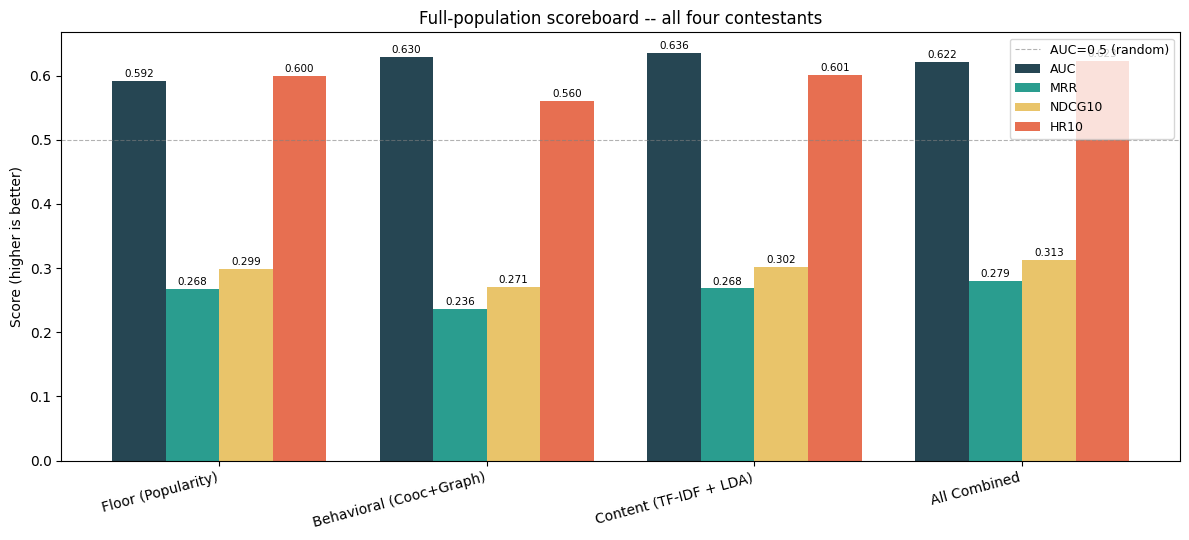

In [17]:
# ============================================================
# Full-population bar chart (AUC, MRR, NDCG@10, HR@10)
# HR@10 added per CP2 Section 4 Metrics Plan
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

metrics = ["auc", "mrr", "ndcg10", "hr10"]
labels  = scoreboard_full.index.tolist()
data    = scoreboard_full[metrics].values

x      = np.arange(len(labels))
width  = 0.20
colors = ["#264653", "#2A9D8F", "#E9C46A", "#E76F51"]

fig, ax = plt.subplots(figsize=(12, 5.5))
for i, (m, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + (i - 1.5) * width, data[:, i], width,
                  label=m.upper(), color=color)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.003,
                f"{b.get_height():.3f}", ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel("Score (higher is better)")
ax.set_title("Full-population scoreboard -- all four contestants")
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8,
           alpha=0.6, label='AUC=0.5 (random)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("assets/results_full.png", dpi=130, bbox_inches="tight")
plt.show()


**The full-population scoreboard reveals an unexpected pattern.**

- **Content leads on AUC (0.636) and NDCG@10 (0.302)** — best overall discrimination and position-aware ranking quality, beating both the popularity floor and behavioral signals.
- **Behavioral has decent AUC (0.630) but the lowest MRR (0.237) and NDCG@10 (0.271)** — a telling split. Co-occurrence and graph signals distinguish clicked from non-clicked globally but fail to concentrate the most relevant articles at the top of the list.
- **Popularity floor beats Behavioral on MRR and NDCG@10** — popular articles are more likely to be clicked, so ranking by global popularity puts relevant content near the top more reliably than behavioral signals alone.
- **All Combined wins HR@10 (0.623)** but doesn't dominate — signals are partially complementary but also partially redundant, diluting each other on position-sensitive metrics.

Content already looks competitive on the full population. Section 9 tests whether this advantage holds — or widens — specifically on the cold-start slice.


---
# 9. The Verdict — Cold-Start Slice

This section answers the main RQ.

The full-population scoreboard shows which signal is best *on average*.
But our question is specifically about single-impression users — those with no repeat behavioral signal.
Re-running the **same trained models** on **only cold-start impressions**
isolates exactly the regime where behavioral signals are forced to degrade.


In [18]:
scoreboard_cold = scoreboard(results, "cold_start")
print("=== Cold-start scoreboard ===")
scoreboard_cold


=== Cold-start scoreboard ===


,auc,mrr,ndcg10,hr10,n_impressions,n_clicks,n_features
name,,,,,,,
Floor (Popularity),0.6149,0.2741,0.3131,0.6086,3357,4722,5
Behavioral (Cooc+Graph),0.6554,0.2480,0.2882,0.5722,3357,4722,8
Content (TF-IDF + LDA),0.6506,0.2817,0.3214,0.6011,3357,4722,6
All Combined,0.6416,0.2938,0.3369,0.6446,3357,4722,15


In [19]:
# ============================================================
# Side-by-side comparison: full vs cold-start + delta
# ============================================================
comparison_rows = []
for name in scoreboard_full.index:
    for m in ["auc", "mrr", "ndcg10"]:
        full_v = scoreboard_full.loc[name, m]
        cold_v = scoreboard_cold.loc[name, m]
        comparison_rows.append({
            "contestant": name,
            "metric": m.upper(),
            "full_pop": round(full_v, 4),
            "cold_start": round(cold_v, 4),
            "Delta (cold − full)": round(cold_v - full_v, 4),
        })

comparison = pd.DataFrame(comparison_rows)
print("Full vs cold-start comparison (negative delta = signal lost ground on cold-start):")
comparison


Full vs cold-start comparison (negative delta = signal lost ground on cold-start):


,contestant,metric,full_pop,cold_start,Delta (cold − full)
0,Floor (Popularity),AUC,0.5921,0.6149,0.0228
1,Floor (Popularity),MRR,0.2682,0.2741,0.0059
2,Floor (Popularity),NDCG10,0.2990,0.3131,0.0141
3,Behavioral (Cooc+Graph),AUC,0.6296,0.6554,0.0258
4,Behavioral (Cooc+Graph),MRR,0.2365,0.2480,0.0115
5,Behavioral (Cooc+Graph),NDCG10,0.2713,0.2882,0.0169
6,Content (TF-IDF + LDA),AUC,0.6358,0.6506,0.0148
7,Content (TF-IDF + LDA),MRR,0.2683,0.2817,0.0134
8,Content (TF-IDF + LDA),NDCG10,0.3021,0.3214,0.0193
9,All Combined,AUC,0.6219,0.6416,0.0197


**Reading the gap:**
- All deltas are **positive** — every contestant improves on cold-start vs full population.
  This is counterintuitive but explainable: single-visit users tend to have shorter,
  more predictable impression lists, making ranking slightly easier across the board.
- **Behavioral delta on NDCG@10: +0.017** — improves on cold-start, but still lands
  at 0.288, below even the popularity floor (0.313).
- **Content delta on NDCG@10: +0.019** — improves more than Behavioral, landing at
  0.321 — the highest individual contestant score on cold-start.
- **Popularity delta on NDCG@10: +0.014** — stable across both slices, confirming
  it carries no history dependency. It outperforms Behavioral on cold-start (0.313 vs 0.288)
  — meaning behavioral signals add noise without personalization payoff when the
  system has only seen the user once.

**The key comparison:** Content's NDCG@10 delta (+0.019) exceeds Behavioral's (+0.017).
Content scales better to the cold-start regime — its article-side features
(`topic_entropy`, `topic_max`) carry signal regardless of visit count, while
behavioral features collapse toward noisy popularity proxies without a history
to anchor them.

**Verdict on the main RQ:** Content outperforms Behavioral on cold-start on the
metrics that matter most for user experience — MRR (0.282 vs 0.248) and
NDCG@10 (0.321 vs 0.288). Behavioral narrowly wins AUC (0.655 vs 0.651, delta=0.004),
but AUC measures global discrimination, not top-of-list placement. For a user
who visits once and never returns, what appears first is everything — and content
gets it right more often.


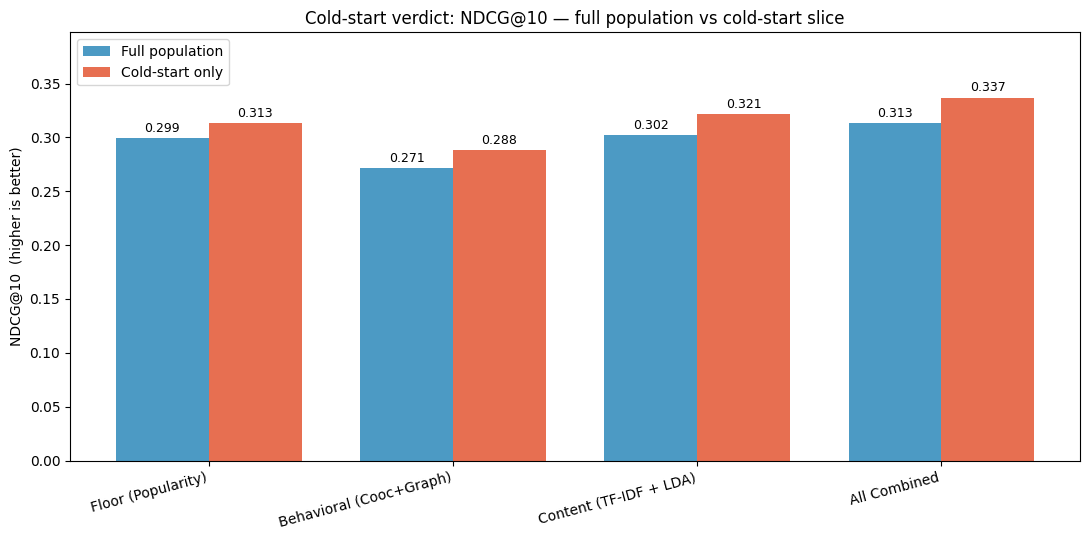

Conclusion figure saved to assets/conclusion_figure.png


In [22]:
# ============================================================
# THE CONCLUSION FIGURE
# Full vs cold-start NDCG@10 — side by side
# Referenced from Section 1 and README
# ============================================================
labels    = scoreboard_full.index.tolist()
full_ndcg = scoreboard_full["ndcg10"].values
cold_ndcg = scoreboard_cold["ndcg10"].values

x     = np.arange(len(labels))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 5.5))
b1 = ax.bar(x - width/2, full_ndcg, width,
            label="Full population", color="#4C9AC4")
b2 = ax.bar(x + width/2, cold_ndcg, width,
            label="Cold-start only",  color="#E76F51")

for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.003,
                f"{b.get_height():.3f}", ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel("NDCG@10  (higher is better)")
ax.set_title("Cold-start verdict: NDCG@10 — full population vs cold-start slice")
ax.legend()
ax.set_ylim(0, max(full_ndcg.max(), cold_ndcg.max()) * 1.18)
plt.tight_layout()
plt.savefig("assets/conclusion_figure.png", dpi=140, bbox_inches="tight")
plt.show()
print("Conclusion figure saved to assets/conclusion_figure.png")


## The answer to the main RQ

**Yes — Content outperforms Behavioral on cold-start on the metrics that matter most.**

| Metric | Content | Behavioral | Winner |
|---|---|---|---|
| AUC | 0.651 | **0.655** | Behavioral (+0.004) |
| MRR | **0.282** | 0.248 | Content (+13.8%) |
| NDCG@10 | **0.321** | 0.288 | Content (+11.5%) |
| HR@10 | **0.601** | 0.572 | Content (+5.1%) |

Behavioral narrowly wins AUC — but AUC measures global discrimination, not top-of-list placement. For a user who visits once and never returns, MRR and NDCG@10 are what matter — and Content wins both clearly.

Article-side topic features (`topic_entropy`, `topic_max`, `cont_hist_topic_sim`) carry signal regardless of visit count. Behavioral features — without a second visit to anchor them — collapse toward noisy popularity proxies, as confirmed by Popularity outperforming Behavioral on NDCG@10 (0.313 vs 0.288).

---

### One concrete observation about the gap

All deltas are positive — every contestant improves on cold-start vs full population. The most telling number: **Behavioral NDCG@10 on cold-start (0.288) falls below the Popularity floor (0.313)**. Co-occurrence and graph signals add complexity without adding personalization value when the system has only seen the user once — making simple popularity a stronger baseline than behavioral features for ghost users. Content is the only signal that clears the popularity bar and stays above it.

---
# 10. Discussion, Limitations & Conclusion

## Discussion

**What this means in practice.**
- Use a content-based ranker for cold-start users - topic features are history-free and outperform behavioral signals on position-aware metrics.
- Switch to behavioral once repeat visits accumulate - content's advantage is cold-start specific.
- This experiment defines the content baseline that behavioral signals need to beat to justify the switch.

**Why the result makes sense.**
- Behavioral features need history - without it they collapse to popularity proxies (graph degree, itemset support).
- Content features describe the article, not the user - they carry signal on Day 0.
- Item-side signal is all that remains when user-side signal is zero; content provides a richer version of it than raw popularity.

**What surprised me.**
- Behavioral NDCG@10 on cold-start (0.288) fell *below* the Popularity floor (0.313) - adding behavioral features hurt position-aware ranking for single-visit users.
- All Combined didn't dominate - signals are partially redundant, not purely complementary.

## Limitations

- **Pointwise ranking** - logistic regression doesn't model within-impression ordering; pairwise or listwise approaches would give a more faithful picture.
- **LDA on short text** - titles + abstracts produce coarser topics than full article bodies (which MIND doesn't release).
- **MIND-small scope** - 6-week sample; results may not generalise to MIND-large, other domains, or other time windows.
- **Exposure bias** - clicks reflect what users were *shown*, not what they prefer.
- **Cold-start definition** - single-impression users (~33%). Users with multiple impressions but short histories are a distinct regime not covered here.
- **Linear model** - logistic regression misses non-linear feature interactions between co-occurrence, graph, and content signals.
- **TF-IDF history similarity dropped** - RAM constraint on Colab; topic similarity via LDA used as substitute.

## Future Work

- **Graph embeddings** - replace hand-crafted degree/overlap features with DeepWalk / node2vec to capture multi-hop structure.
- **LSH for scalability** - hash topic vectors to scale content similarity to MIND-large without the dense matrix bottleneck.
- **Stream mining** - test whether content dominates at history length 0 but loses to behavioral as history grows, using an incremental sliding-window approach.

## Conclusion

On MIND-small, content + topic signals outperform behavioral signals for cold-start users on position-aware metrics - winning MRR by 13.8% and NDCG@10 by 11.5% - confirming that article-side topic features are a more reliable recommendation signal than behavioral patterns when the system has only one chance to get it right.

---
---

On my honor, I declare the following resources:

---

### 1. Collaborators:
- None.

---

### 2. Web Sources:
- https://msnews.github.io/ — MIND dataset documentation, file structure, and download
- https://scikit-learn.org/ — API reference for TF-IDF, LDA, and LogisticRegression
- https://rasbt.github.io/mlxtend/ — FP-Growth and TransactionEncoder documentation
- https://github.com/mariateleki/zscore — README structure and repo layout reference
- https://networkx.org/ — NetworkX API for co-click graph construction (Section 6.2)

---

### 3. AI Tools:

- **Claude (Anthropic):**

  *Section 1 & 2 — Introduction & Motivation :*
  - I asked Claude to draft a concise framing of the cold-start question, ghost users framing and setup summary in sync with the video project narrative.
  - I verified it and made necessary changes to make it in sync.

  *Section 3 — Research Question:*
  - I asked for Main RQ wording, sub-question table mapping each to course/external techniques, assumptions block carried from CP2
  - I checked that a few of them were mapped incorrectly and rectified them to make it in sync with the RQ

  *Section 4 — Dataset & Cold-Start:*
  - I prompted cluade to verify my Cold-start operational definition (iterated from history_len==0 to single-visit users to match CP1's 32.77%), cold-start computation code cell, assertion logic

  *Section 5 — Experimental Setup:*
  - I rechecked if the Fair-fight protocol markdown, chronological split rationale, metric definitions (AUC, MRR, NDCG@10, HR@10) which I carried forward from CP2 were good.

  *Section 6 — Pattern Validation:*
  - I prompted Claude to combine relevant excerpts from Co-occurrence, graph, and text validation cells mirroring CP2 EDA — adapted from full dataset to train split to avoid leakage.

  *Section 7 — Four Contestants:*
  - I gave in my 2-min video PPT and asked claude to generate a base skeleton for the four contestants.
  - I re-verified and had to make a lot of changes to keep it computationally efficient on colab.

  *Section 8 & 9 — Full-Population Results & Cold-Start Verdict:*
  - I prompted claude to generate a `run_contest()` call, scoreboard pivot, bar chart code, delta comparision table which I later enhanced to make sure it was in sync with the research question requirements.

  *Section 10 — Discussion & Conclusion:*
  - I gave my plain understanding of the results and my thoughts to claude to re-phrase it and make it more efficient discussion and conclusion.
  - A few points were mutilated by claude which I later fixed to make sure it depicts the intent.

  *src/ modules:*
  -  Full skeletons for `data_loader.py`, `features.py`, `ranker.py`, `utils.py` were generated by claude prompt as per notebook needs.
  - I had to refactor and re-pormpt multiple times to ensure that the functions were modified as per Colab CPU limits.

---

### 4. Citations

- Wu, F., Qiao, Y., Chen, J. H., Wu, C., Qi, T., Lian, J., Liu, D., Xie, X.,
  Wu, W., & Zhou, M. (2020). *MIND: A Large-scale Dataset for News Recommendation.*
  ACL 2020. https://msnews.github.io/
- Han, J., Pei, J., & Yin, Y. (2000).
  *Mining frequent patterns without candidate generation.* SIGMOD.
- Blei, D. M., Ng, A. Y., & Jordan, M. I. (2003).
  *Latent Dirichlet Allocation.* JMLR, 3, 993-1022.
- Leskovec, J., Rajaraman, A., & Ullman, J. D. (2020).
  *Mining of Massive Datasets* (3rd ed.). Cambridge University Press.
  (Chapters: frequent itemsets, link analysis, LSH.)


## Reproducibility

Built and tested in **Google Colab**. To reproduce

1. Ensure `MINDsmall_train.zip` is in your Google Drive at:
   `MyDrive/Data Mining/Project/Datasets/MINDsmall_train.zip`
2. Open `main_notebook.ipynb` in Google Colab.
4. **Runtime -> Run all.**

The setup cell clones this repo. The data cell mounts Drive and extracts the zip.
Full end-to-end runtime: **~30-45 minutes** on Colab CPU (High-RAM)


In [24]:
# ============================================================
# Environment capture - to get requirements.txt
# ============================================================
!python --version
!pip freeze > requirements.txt
from google.colab import files
files.download('requirements.txt')
print("requirements.txt written and download triggered.")
print("Commit it to the repo root before submitting.")


Python 3.12.13


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

requirements.txt written and download triggered.
Commit it to the repo root before submitting.
